In [1]:
import pandas as pd
import numpy as np

url_data = "https://docs.google.com/spreadsheets/d/1hmH7aVkADkHk3Un8rxGYFb4Xail0sWbK/export?format=csv"
df = pd.read_csv(url_data)
df["sales_date"] = pd.to_datetime(df["sales_date"])

print("Data berhasil di-load!")
print("Jumlah baris dan kolom:", df.shape)
df.head()


Data berhasil di-load!
Jumlah baris dan kolom: (10000, 16)


,sales_date,order_id,customer_name,customer_address,product_name,category,unit,price,quantity,order_type,distance_km,discount,total,shipping_fee,total_sales,status
0,2025-07-17,RMP00001,Customer_1198,"Kecamatan Cicalengka, Kabupaten Bandung",Bunga Lawang (Pekak),Rempah Kering & Bumbu Dapur,50 gr,9000,1,Beli di Toko,0,0,9000,0,9000,completed
1,2025-09-11,RMP00002,Customer_3969,"Kecamatan Gedebage, Kota Bandung",Kencur,Rempah & Sayuran Segar,250 gr,8000,1,Beli di Toko,0,0,8000,0,8000,completed
2,2025-11-15,RMP00003,Customer_575,"Kecamatan Padalarang, Kabupaten Bandung Barat",Paket Bumbu Gule Sapi,Paket Bumbu Instan,1 paket,15000,2,Diantar (Aplikasi Toko),"14,2",0,30000,25000,55000,completed
3,2025-06-06,RMP00004,Customer_1394,"Kecamatan Cisarua, Kabupaten Bandung Barat",Paket Bumbu Soto Betawi,Paket Bumbu Instan,1 paket,22000,1,Beli di Toko,0,0,22000,0,22000,completed
4,2025-12-13,RMP00005,Customer_1382,"Kecamatan Sukajadi, Kota Bandung",Paket Bumbu Woku Manado,Paket Bumbu Instan,1 paket,20000,1,Diantar (Aplikasi Toko),"1,5",0,20000,0,20000,completed


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[us]
 1   order_id          10000 non-null  str           
 2   customer_name     10000 non-null  str           
 3   customer_address  10000 non-null  str           
 4   product_name      10000 non-null  str           
 5   category          10000 non-null  str           
 6   unit              10000 non-null  str           
 7   price             10000 non-null  int64         
 8   quantity          10000 non-null  int64         
 9   order_type        10000 non-null  str           
 10  distance_km       10000 non-null  str           
 11  discount          10000 non-null  str           
 12  total             10000 non-null  int64         
 13  shipping_fee      10000 non-null  int64         
 14  total_sales       10000 non-null  

--- Merge Data ---

In [3]:
print(df.columns)
print(df["product_name"].unique())

Index(['sales_date', 'order_id', 'customer_name', 'customer_address',
       'product_name', 'category', 'unit', 'price', 'quantity', 'order_type',
       'distance_km', 'discount', 'total', 'shipping_fee', 'total_sales',
       'status'],
      dtype='str')
<StringArray>
[         'Bunga Lawang (Pekak)',                        'Kencur',
         'Paket Bumbu Gule Sapi',       'Paket Bumbu Soto Betawi',
       'Paket Bumbu Woku Manado',    'Paket Bumbu Kerupuk Sambal',
                          'Jahe',          'Cabai Merah Keriting',
                     'Asam Jawa',      'Paket Bumbu Semur Daging',
         'Paket Bumbu Ayam Rica',                  'Daun Kemangi',
                    'Daun Jeruk',                  'Merica Hitam',
       'Paket Bumbu Dasar Merah',      'Paket Bumbu Sambal Hijau',
                  'Vanili Bubuk',      'Paket Bumbu Terik Daging',
        'Paket Bumbu Ayam Bakar',              'Paket Bumbu Bali',
    'Paket Bumbu Tumis Kangkung',             'Cabai Rawi

In [4]:
gudang = pd.DataFrame({
    "product_name": ["Beras", "Minyak Goreng", "Gula Pasir", "Teh Celup", "Kopi Bubuk"],
    "stok": [120, 60, 85, 200, 45]
})

Merge and Check 

In [5]:
print(df.shape)

hasil = pd.merge(df, gudang, on="product_name", how="left")

print(hasil.shape)                    # baris harus sama kayak df
print(hasil["stok"].isnull().sum())   # produk yang nggak ketemu di gudang

(10000, 16)
(10000, 17)
10000


Bikin Kolom 'Bulan'

In [6]:
df["sales_date"] = pd.to_datetime(df["sales_date"])
df["bulan"] = df["sales_date"].dt.strftime("%Y-%m")   # contoh: "2024-01"

long → wide (pivot_table)

Isi kolom category (Rempah, Sembako) naik jadi judul kolom.

tujuannya:
untuk laporan 

In [7]:
wide = df.pivot_table(index="bulan",          # baris: tiap bulan
columns="category",     # kolom: tiap category
values="total",         # angka yang dirangkum (kolom asli di df)
aggfunc="sum",          # 'sum' (jumlah), 'mean' (rata-rata), 'count' (banyak transaksi)
fill_value=0            # kombinasi bulan + category tanpa transaksi diisi 0, bukan NaN
)

print(wide)

category  Paket Bumbu Instan  Rempah & Sayuran Segar  \
bulan                                                  
2025-01             19944150                 2854550   
2025-02             19495000                 2677400   
2025-03             21413050                 2740925   
2025-04             21446300                 2976350   
2025-05             22101300                 2698725   
2025-06             18681700                 2880350   
2025-07             21649750                 3164950   
2025-08             22720650                 3487825   
2025-09             20370000                 2758650   
2025-10             20723950                 3251175   
2025-11             19025600                 2797525   
2025-12             22395200                 3421550   

category  Rempah Kering & Bumbu Dapur  
bulan                                  
2025-01                       3456375  
2025-02                       3183900  
2025-03                       3006525  
2025-04        

In [8]:
wide['total'] = wide.sum(axis=1)
#    ^^^^^^^     ^^^^^^^^^^^^^^
#    nama kolom  isinya dari mana
#    baru        (dihitung dari wide)

wide → long (melt)

Judul kolom (Rempah, Sembako) turun jadi isi satu kolom, atau hasil melt() dari 'wide'

tujuannya :
untuk di buat grafik atau ploting nanti nya


In [9]:
long = (wide.drop(columns='total')  # buang kolom total, biar nggak kebaca sebagai category
.reset_index()                      # bulan dari index jadi kolom biasa
.melt(id_vars="bulan",              # bulan dibiarin apa adanya
var_name="category",               # judul kolom (Rempah, Sembako) turun jadi isi kolom ini
value_name="pendapatan"))          # angka di sel jadi isi kolom ini

print(long.head())

     bulan            category  pendapatan
0  2025-01  Paket Bumbu Instan    19944150
1  2025-02  Paket Bumbu Instan    19495000
2  2025-03  Paket Bumbu Instan    21413050
3  2025-04  Paket Bumbu Instan    21446300
4  2025-05  Paket Bumbu Instan    22101300


- Ploting / Visualisasi Data Langsung Dari Data Frame:

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_9528\972462143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=per_category.index, y=per_category.values, palette="YlOrBr")


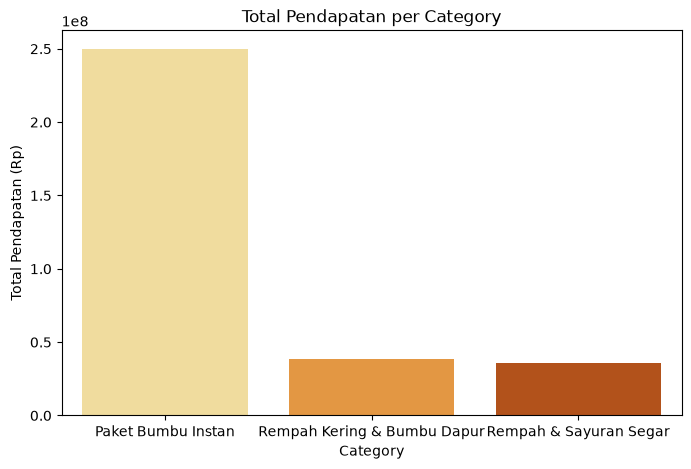

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

per_category = df.groupby("category")["total"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=per_category.index, y=per_category.values, palette="YlOrBr")
plt.title("Total Pendapatan per Category")
plt.xlabel("Category")
plt.ylabel("Total Pendapatan (Rp)")
plt.show()

Kode di Bawah berarti:

"cuma setelan tampilan, nggak ngitung apa-apa.
Artinya: semua angka desimal yang ditampilkan pandas dibulatin ke 0 desimal dan dikasih pemisah ribuan."

"{:,.0f}: , = pemisah ribuan, .0f = 0 angka di belakang koma
Tanpa ini, angka gede kadang muncul kayak 1.523457e+05, susah dibaca
Setelan ini berlaku sampai notebook lo direstart. Datanya sendiri nggak berubah, cuma cara nampilinnya"

In [11]:

pd.options.display.float_format = "{:,.0f}".format   # biar angka nggak ditulis 1.5e+05
# nggak ngitung apa-apa. Artinya: semua angka desimal yang ditampilkan pandas dibulatin ke 0 desimal dan dikasih pemisah ribuan.


print(df["total"].describe()) 
# df["total"] ambil satu kolom (Series), .describe() ngitung ringkasan statistiknya sekaligus

count    10,000
mean     32,386
std      25,842
min       2,700
25%      14,000
50%      24,000
75%      44,000
max     160,000
Name: total, dtype: float64


In [12]:
# menerima dictionary dengan format {nama_kolom: [daftar fungsi]}:
df.agg({"total": ["mean", "median", "std"]})

#"total" = kolom yang dihitung ["mean", "median", "std"] = tiga hitungan yang dijalanin

,total
mean,"32,386"
median,"24,000"
std,"25,842"


In [13]:
print(df["total"].skew())

1.6274482584062437


In [14]:
df.groupby("category")["total"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
category,,,,
Paket Bumbu Instan,6007,"41,613","32,000","27,639"
Rempah & Sayuran Segar,2002,"17,837","13,500","14,948"
Rempah Kering & Bumbu Dapur,1991,"19,178","15,000","13,448"


Transaksi Ekstrem :

In [15]:
q1 = df["total"].quantile(0.25)
q3 = df["total"].quantile(0.75)
batas = q3 + 1.5 * (q3 - q1)

grosir = df[df["total"] > batas]
print("Batas ekstrem:", batas)
print("Jumlah transaksi ekstrem:", len(grosir))
print(grosir.sort_values("total", ascending=False).head())

Batas ekstrem: 89000.0
Jumlah transaksi ekstrem: 396
     sales_date  order_id  customer_name  \
364  2025-12-01  RMP00365  Customer_3063   
123  2025-08-02  RMP00124  Customer_1190   
7121 2025-09-12  RMP07122  Customer_3647   
7188 2025-02-14  RMP07189  Customer_3011   
6974 2025-10-11  RMP06975  Customer_2519   

                                   customer_address  \
364            Kecamatan Ujung Berung, Kota Bandung   
123                Kecamatan Sukajadi, Kota Bandung   
7121              Kecamatan Arcamanik, Kota Bandung   
7188  Kecamatan Padalarang, Kabupaten Bandung Barat   
6974               Kecamatan Gedebage, Kota Bandung   

                   product_name            category     unit  price  quantity  \
364       Paket Bumbu Rica-Rica  Paket Bumbu Instan  1 paket  32000         5   
123    Paket Bumbu Sambal Hijau  Paket Bumbu Instan  1 paket  32000         5   
7121  Paket Bumbu Coto Makassar  Paket Bumbu Instan  1 paket  32000         5   
7188   Paket Bumbu Sambal H

- Ploting Line Chart -

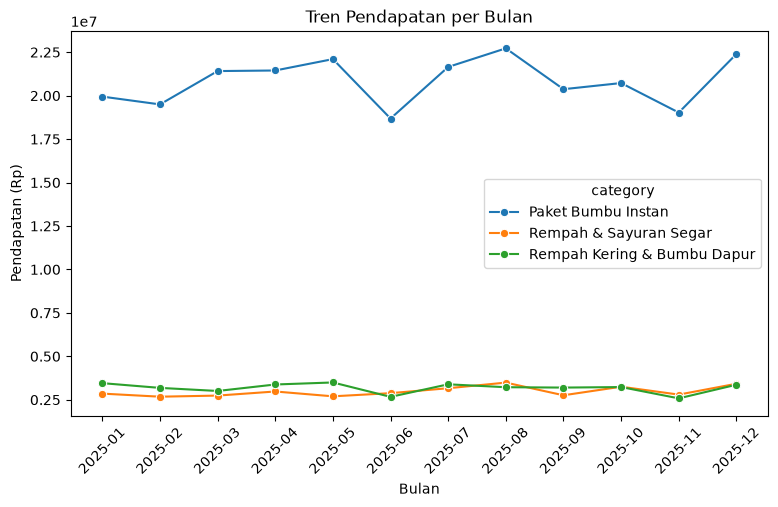

In [16]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=long, x="bulan", y="pendapatan", hue="category", marker="o")
plt.title("Tren Pendapatan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Pendapatan (Rp)")
plt.xticks(rotation=45)
plt.show()

- Ploting Histogram

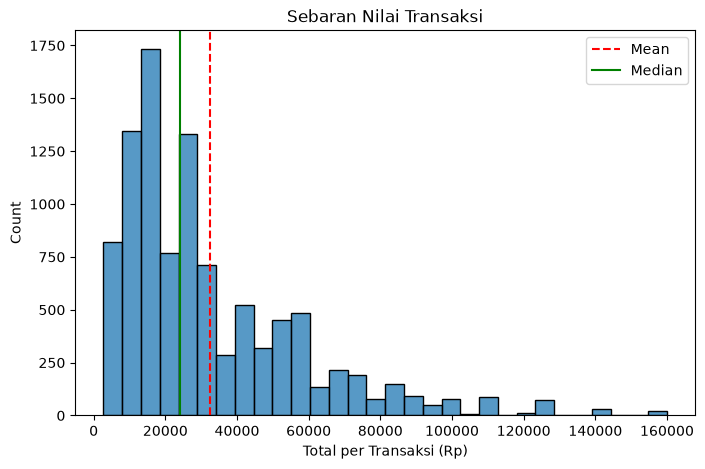

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["total"], bins=30)
plt.axvline(df["total"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["total"].median(), color="green", linestyle="-", label="Median")
plt.title("Sebaran Nilai Transaksi")
plt.xlabel("Total per Transaksi (Rp)")
plt.legend()
plt.show()

- Ploting Heatmap Kolerasi

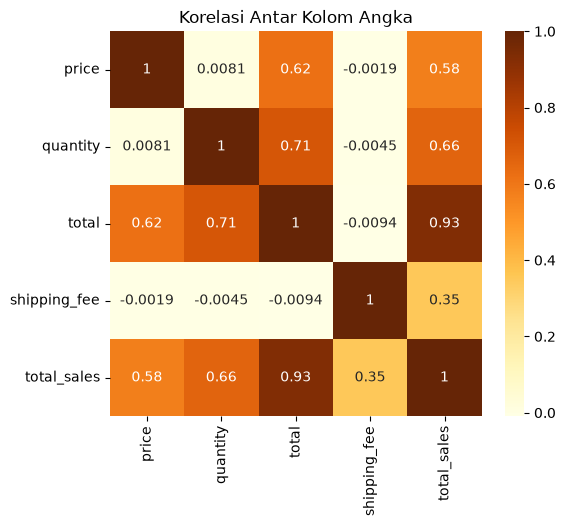

In [18]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="YlOrBr")
plt.title("Korelasi Antar Kolom Angka")
plt.show()